# Day 018 · 几何布朗运动
**Geometric Brownian Motion** · 阶段 P1 · 量化基础

> 几何布朗运动是 Black-Scholes 期权定价模型的数学心脏,也是几乎所有衍生品估值的入门假设。本课从微分方程 dS = μS dt + σS dW 出发,推导对数离散形式,讲清为什么 GBM 给出的是对数正态分布而不是正态分布。然后用 numpy 一百行内写出 GBM 模拟器,生成中国平安未来一年的一千条价格路径,把「逐步推进」和「解析解一步到位」两种实现都做出来对照。但课的真正问题不在这里 — 真正的问题是:**GBM 这个数学工具在多大程度上能描述真实股价?** 我们用四只标的(中国平安、宁德时代、特斯拉、比亚迪)做实证,把 GBM 模拟出来的一年收益分布和历史实际滚动一年收益分布画在一起,再做 Jarque-Bera 正态性检验和 Q-Q plot,看 GBM 假设漏在哪里、漏了多少。理解 GBM 的边界比熟练它的公式更重要 — 否则你学完 BS 期权定价上手就要踩跳跃和厚尾的坑。

---

**课件生成日期:** 2026-05-05  ·  **建议学习时长:** 22 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 看懂 GBM 微分方程 dS = μS dt + σS dW 的每个符号含义,并能推出对数离散形式 d ln S = (μ - σ²/2) dt + σ dW
- 理解 GBM 解析解 S_T = S_0 × exp((μ - σ²/2) T + σ √T Z) 为什么自动给出对数正态分布
- 用 numpy 写出两种 GBM 模拟器(逐步推进 vs 解析一步),知道二者结果分布相同但用途不同
- 用 Jarque-Bera 检验和 Q-Q plot 量化诊断 GBM 假设(日对数收益正态)在真实股票上的偏离程度
- 明白 GBM 的两大缺陷 — 没有跳跃 / 没有厚尾,以及为什么它仍然是 BS 模型和金融教科书的入门基准

## 历史背景:GBM 的故事 — 从布朗 1827 到 Bachelier 1900 到 Samuelson 1965

几何布朗运动的故事要从一八二七年的英国植物学家 Robert Brown 讲起。他在显微镜下观察水中花粉颗粒,发现它们在做无规则的颤动 — 这就是布朗运动。但当时没有人能解释为什么。直到一九零五年,Albert Einstein 在他著名的「奇迹年」论文里给出了数学解释:这些颤动是水分子热运动撞击花粉的统计结果,可以用一个随机过程精确描述。同一年法国数学家 Henri Poincaré 的学生 Louis Bachelier 在他的博士论文《投机理论》(一九零零年答辩,比 Einstein 还早五年)里第一次把布朗运动用到金融 — 他用算术布朗运动 dS = μ dt + σ dW 来建模巴黎交易所的债券价格,这是金融工程的开山之作。但是 Bachelier 的论文当时被法国数学界冷落,因为算术布朗运动有个致命问题:股价可以变成负数,这显然不对。

直到一九六五年,经济学家 Paul Samuelson(MIT 教授,一九七零年诺贝尔经济学奖得主)在他的论文《Rational Theory of Warrant Pricing》里把 Bachelier 的算术布朗运动改成几何布朗运动 dS / S = μ dt + σ dW —— 也就是说,变化的不是股价本身,而是股价的「比例变化」。这一改自动解决了股价负数问题(因为 GBM 的解 S_T = S_0 × exp(...) 永远为正),并且让股价分布从正态变成对数正态(右偏,跟现实股价直方图形状吻合)。Samuelson 的这个改进是后来一九七三年 Fischer Black、Myron Scholes、Robert Merton 推导欧式期权解析公式的核心假设 — Black-Scholes-Merton 模型直接架在 GBM 之上,后两者拿了一九九七年诺贝尔经济学奖。

但 GBM 不是真理。一九六三年,法国数学家 Benoît Mandelbrot 在他的论文《The Variation of Certain Speculative Prices》里第一次系统地实证棉花价格,发现日收益分布远比正态更厚尾,极端事件比 GBM 假设密集得多。后来 Nassim Taleb 把这个观察推到极致 — 他的《黑天鹅》《反脆弱》整套理论都是在批 GBM 这种「假设正态、实际厚尾」的模型在尾部完全不可信。所以今天的我们一边用 GBM 做基准、做入门、做教学,一边知道它在尾部漏洞百出 — 严肃的实战风控用 GARCH + t 残差或经验分布,而不是 GBM。理解这个张力,你才算真懂期权定价。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 几何布朗运动 GBM 的微分方程定义

**核心方程**:dS = μ S dt + σ S dW

这里每个符号要拆开看:
- **dS**:股价的瞬时变化量
- **dt**:时间的瞬时变化量(无穷小)
- **dW**:Wiener 过程(标准布朗运动)的瞬时变化量,服从 dW ~ N(0, dt)
- **μ**:漂移率(drift,瞬时期望年化收益,单位 1/年)
- **σ**:波动率(volatility,瞬时年化标准差,单位 1/√年)
- **μ S dt**:确定性部分,代表平均增长(像复利的 r dt)
- **σ S dW**:随机部分,代表随机波动

**两个方程都成立的等价形式**(应付不同推导):
- dS / S = μ dt + σ dW(乘性形式 · 直观)
- d ln S = (μ - σ²/2) dt + σ dW(对数形式 · 用伊藤引理推出)

这两个公式不一样,差一个 -σ²/2(伊藤修正项)。这个修正在解析解里至关重要,丢了就错。

```
dS = μ S dt + σ S dW   ⟺   dS / S = μ dt + σ dW   ⟺   d ln S = (μ - σ²/2) dt + σ dW
```

> **举例:** 想象一只年化漂移 μ = 8% / 年化波动 σ = 25% / 当前价 S = 100 的股票,在一个非常短的时间(一天 = 1/252 年)里:确定性涨幅约 8% × 1/252 ≈ 0.032%,随机噪声标准差约 25% × √(1/252) ≈ 1.57%。所以一天的预期变化是 0.032 ± 1.57 元,随机部分远大于确定部分 — 短期股价基本是噪声。


### 2. GBM 的解析解 — 为什么终值是对数正态

把 d ln S = (μ - σ²/2) dt + σ dW 从 0 积分到 T:

**ln(S_T / S_0) = (μ - σ²/2) T + σ √T Z**,其中 Z ~ N(0, 1)

两边取指数:

**S_T = S_0 × exp((μ - σ²/2) T + σ √T Z)**

这就是 GBM 的解析解。它告诉我们三件大事:
1. **S_T 永远为正**(指数函数永远 > 0),解决了 Bachelier 算术布朗运动股价负数问题
2. **ln(S_T / S_0) 服从正态**(因为 Z 是正态的线性变换),所以 **S_T 服从对数正态分布**
3. **对数正态是右偏的** — 均值 > 中位 > 众数,跟股票收益直方图形状吻合

对数正态的均值和中位是不同的:
- E[S_T] = S_0 × exp(μ T)(几何 / 数学期望)
- Median[S_T] = S_0 × exp((μ - σ²/2) T)(中位)

注意中位用的是 (μ - σ²/2),均值用的是 μ。这就是为什么散户经常感觉「平均收益不错但我没赚到」 — 你赚到的是中位数,不是均值。波动越大,二者差距越大,这叫**波动拖累**(volatility drag)。

```
S_T = S_0 × exp((μ - σ²/2) T + σ √T Z)   //   E[S_T] = S_0 e^(μT)   //   Median[S_T] = S_0 e^((μ-σ²/2)T)
```

> **举例:** **典型例子 — 波动拖累的代价**:假设两只股票年化漂移都是 μ = 10%,但 A 的波动 σ = 15% / B 的波动 σ = 40%。一年后均值都是 S_0 × e^0.10 ≈ 1.105 倍。但 A 的中位 ≈ 1.094 倍,B 的中位 ≈ 1.020 倍 — B 的中位接近持平。意思是:波动越大,大多数情况下你拿到的回报越接近 0(虽然均值看起来一样)。这就是为什么大波动资产长期持有反而不如小波动 — 波动拖累在吃你的复利。


### 3. 为什么 GBM 是 Black-Scholes 期权定价的基石

Black-Scholes 模型 1973 年推导欧式 call 期权解析公式时,**第一假设**就是「标的价格服从 GBM」。原因有三:

1. **股价永远为正** — GBM 的解析解保证 S_T > 0,符合现实(股价不会负)
2. **对数正态分布有解析期望** — 在「股价对数服从正态」的条件下,期权 payoff max(S_T - K, 0) 的期望可以解析积分,得到著名的 BS 公式 C = S × N(d_1) - K × e^(-rT) × N(d_2)
3. **Δ 对冲是动态可行的** — GBM 假设波动率常数 + 路径连续 + 无跳跃,理论上可以用「连续调整 Delta」复制期权 payoff,这是 BS 推导的根本机制

这三个假设缺一不可。如果股价有跳跃(GBM 没有),Δ 对冲就失败 — 所以 BS 模型对 2020 年三月美股一周熔断 4 次这种事件几乎完全失灵。如果波动率不是常数(实际是聚集的、随时间变的),BS 给出的「公允价」就跟实际市价偏离 — 这个偏离就叫 **波动率微笑**(volatility smile),所有期权交易员都见过。所以 GBM + BS 是入门和教学的标准,实战是「GBM 的修正版」(随机波动率模型 SABR、跳扩散模型 Merton Jump Diffusion 等)。

```
BS Call: C(S, T) = S × N(d_1) - K × e^(-rT) × N(d_2)   //   d_1 = [ln(S/K) + (r + σ²/2)T] / (σ√T)   //   d_2 = d_1 - σ√T
```

> **举例:** Δ 对冲的直观理解:你卖出一份 call,担心股价涨吃亏。Δ 告诉你「股价每涨 1 元,期权价大约涨 Δ 元」。所以你只要持有 Δ 份股票就能对冲。GBM 假设股价路径连续,Δ 可以连续调整;一旦市场跳一下(财报、监管、地缘),Δ 来不及调,对冲失败 — 这就是 1987 年黑色星期一彻底打破 BS 模型可信度的原因。


### 4. GBM 的两大致命缺陷 — 跳跃和厚尾

**缺陷一:GBM 假设股价路径连续(没有跳跃)**

GBM 的 dW 是连续的布朗运动,意味着股价是「连续摇晃」过来的,不会突然跳一下。但现实中股价随时跳:
- 财报公布后开盘跳空(±20% 常见)
- 重大监管(比如 2021 年中国教培「双减」一夜下跌 80%)
- 地缘事件(俄乌战争、川普关税)
- 加密 7×24 没熔断,可以一夜归零(Luna 三天 -100%)

这些跳跃 GBM 完全建模不了。修正方案是 Merton Jump Diffusion(GBM + 泊松跳跃),实战常用。

**缺陷二:GBM 假设日对数收益服从正态(实际是厚尾)**

GBM 推导的关键一步是「日对数收益 = 漂移 + σ × Z,Z ~ N(0,1)」。但实际数据告诉我们:
- 几乎所有股票的日对数收益**超额峰度** > 3(正态 = 0)
- 极端事件(σ > 4)的频率比 GBM 假设密集 5-10 倍
- Jarque-Bera 检验在大样本下几乎全部拒绝正态假设(p 值 < 0.001)

本课实测会用 Jarque-Bera 和 Q-Q plot 量化这个偏离 — 你会看到中国平安、宁德时代、特斯拉、比亚迪四只标的全部拒绝正态。修正方案是用 Student's t 分布(自由度 3-7)代替正态,或者直接用经验分布 bootstrap。

```
Jarque-Bera 检验:JB = (n/6) × (Skew² + Kurt²/4)   p < 0.05 → 拒绝正态假设
```

> **举例:** **1987 黑色星期一标普 -22.6% 在 GBM 下是什么概率?** 假设标普日波动 σ = 1.2%,那 -22.6% 等于 -18.8 σ。在正态分布下这个概率是 1.4 × 10^-79 — 比宇宙原子总数还少。GBM 算这是「宇宙寿命也不会出现一次」。但实际 1987 真发生了。这就是 GBM 在尾部彻底失败的最经典案例。


### 5. GBM 在量化实战里的用法 — 基准、教学、压力测试

尽管有缺陷,GBM 仍是量化金融的工作主力。它的三个**正确用途**:

1. **教学和基准模型** — 给学生讲清楚波动 / 漂移 / 对数正态的关系,以及看懂 BS 公式的逻辑。本课、Day 19 风险中性、Day 20 BS 直觉、Day 21 希腊字母都靠 GBM 当框架。
2. **快速估值** — 路径依赖期权(亚式、回望)解析公式很难推,先用 GBM + 蒙特卡洛跑个估值,跟市价对照,大数量级一致就够。Day 17 就用 GBM 做了亚式期权定价。
3. **退休规划 / 长期组合压力测试** — 长期(10-30 年)中心极限定理把厚尾抹平了,GBM 假设跟实际差距小,可以用 GBM 跑破产率、4% 法则、终值分位等。Day 17 退休规划用的就是 GBM。

它的**不正确用途**:
- 日度 VaR / CVaR / 短期(< 1 月)风控 — 必须用厚尾分布,GBM 低估尾部 5-10 倍
- 期权交易实盘 — 至少用 SABR / Heston(随机波动率)或者 implied vol surface 直接拟合市价
- 加密货币短期 — 7×24 没熔断 + 经常跳跃 + 厚尾极端,GBM 几乎不可用
- 单事件驱动(财报 / 监管) — GBM 不建模跳跃

**记住一条:GBM 是入门和长期工具,日度和实战要修正。**

```
GBM 适用范围 ≈ 长期 (>= 1 年) + 多元(组合 / 蒙特卡洛聚合) + 教学示意   //   GBM 不适用 ≈ 短期 (< 1 月) + 单事件 + 期权实盘 + 加密短期
```

> **举例:** Renaissance Medallion 基金虽然几十年年化 35%,但他们的模型不是 GBM — 是结合 t 分布、经验分布、跳跃模型 + 一万多个微小特征。GBM 在他们体系里只是「很多简化模型之一」。这告诉我们:把 GBM 当真理跑实盘是入门级错误。


## 实操:GBM 路径模拟 + 对数正态验证 + 真实股票尾部诊断(四只标的实证)

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


=== 历史参数(GBM 输入 · 五年日线)===
标的                日漂移 μ_d        日波动 σ_d        年漂移 μ_y        年波动 σ_y        当前价
中国平安              0.0052%          1.69%          1.32%         26.84%      60.10
宁德时代              0.0716%          2.64%         18.04%         41.90%     446.11
特斯拉               0.0651%          3.70%         16.41%         58.72%     445.00
比亚迪               0.0620%          2.39%         15.62%         37.90%     100.44

=== 中国平安 GBM 路径模拟(252 天 · 1000 条)===
起始价 S0 = 60.10
方法 A(逐步)终值: 均值 60.96 / 中位 59.04
方法 B(解析)终值: 均值 60.43 / 中位 57.96
理论中位 = S0 × exp((μ-σ²/2)T) = 58.74
理论均值 = S0 × exp(μ T)         = 60.90  ← 对数正态 → 均值 ≠ 中位

=== GBM 模拟分布 vs 历史实际 1 年滚动收益 ===
标的              GBM 1% 分位     GBM 99% 分位       实际 1% 分位      实际 99% 分位
中国平安              -48.26%         81.46%        -36.11%         51.56%
宁德时代              -58.62%        189.79%        -40.71%        110.09%
特斯拉               -73.77%        304.06%        -65.37%        108.96%
比亚迪               -56.03%        161.8

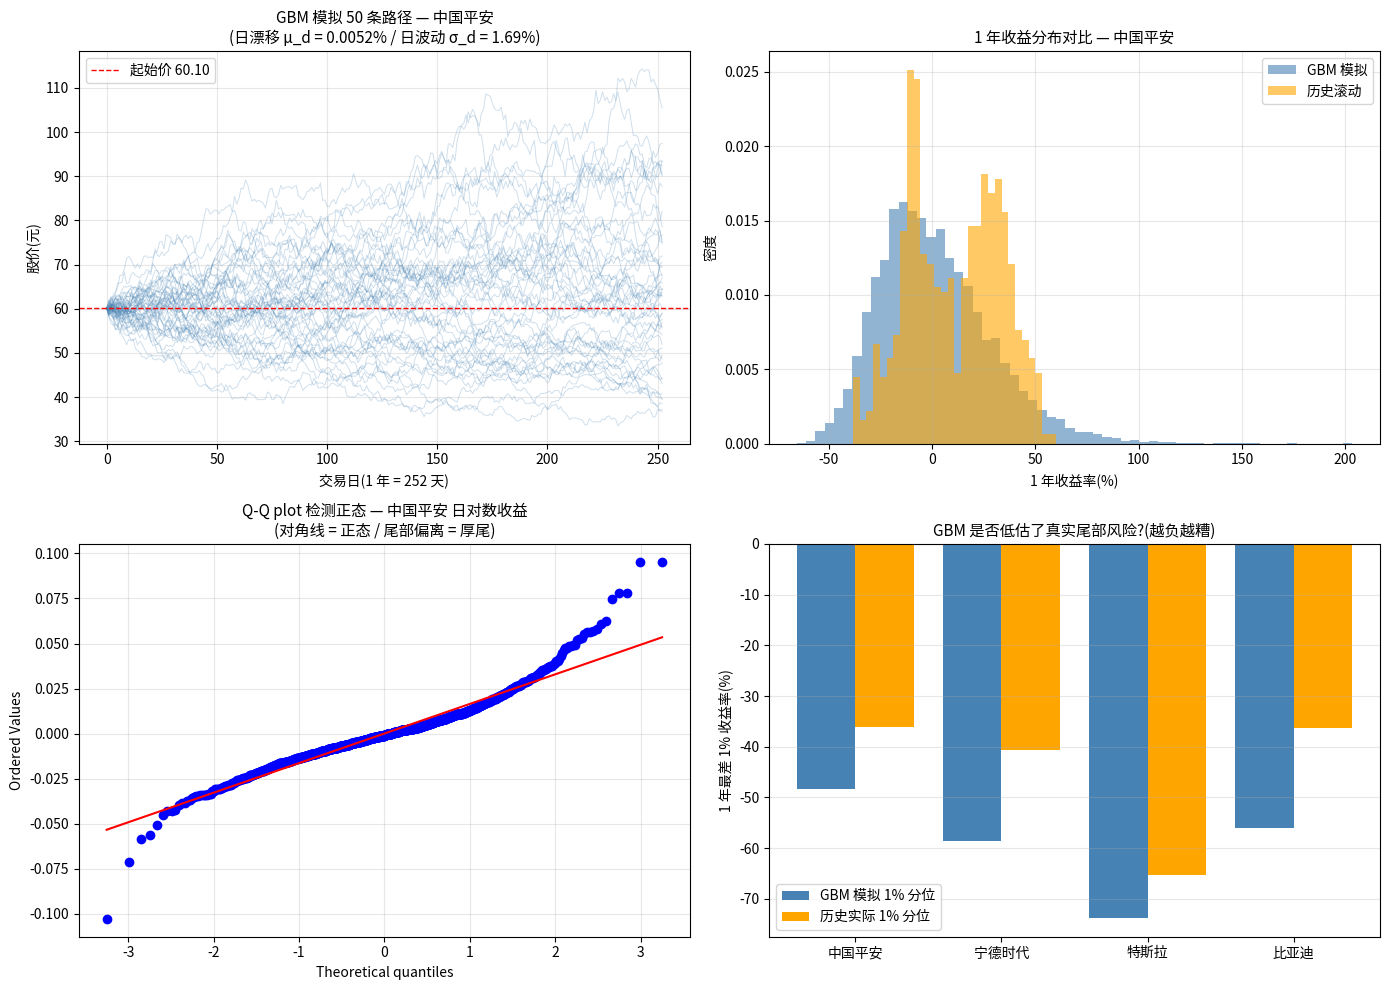

In [2]:
# day_018_gbm.py — 几何布朗运动:从公式到模拟,GBM 多大程度上能描述真实股价
import numpy as np, pandas as pd, yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)

# ============ 1. 拉 4 只多市场标的 5 年日线(各自 dropna,铁律 26)============
tickers = {
    '中国平安': '601318.SS',
    '宁德时代': '300750.SZ',
    '特斯拉':   'TSLA',
    '比亚迪':   '002594.SZ',
}
raw = {}
for name, sym in tickers.items():
    df = yf.download(sym, period='5y', auto_adjust=True, progress=False)['Close']
    raw[name] = df.squeeze().dropna()  # squeeze: 单列 DataFrame → Series(yfinance 兼容)

# ============ 2. 估算每只标的的日度漂移 μ_d / 日度波动 σ_d ============
print('=== 历史参数(GBM 输入 · 五年日线)===')
print(f'{"标的":<10s} {"日漂移 μ_d":>14s} {"日波动 σ_d":>14s} {"年漂移 μ_y":>14s} {"年波动 σ_y":>14s} {"当前价":>10s}')
params = {}
for name, ser in raw.items():
    log_ret = np.log(ser / ser.shift(1)).dropna()
    mu_d, sigma_d = float(log_ret.mean()), float(log_ret.std())
    mu_y, sigma_y = mu_d * 252, sigma_d * np.sqrt(252)
    S0 = float(ser.iloc[-1])
    params[name] = (mu_d, sigma_d, mu_y, sigma_y, S0)
    print(f'{name:<10s} {mu_d*100:13.4f}% {sigma_d*100:13.2f}% {mu_y*100:13.2f}% {sigma_y*100:13.2f}% {S0:10.2f}')

# ============ 3. GBM 路径模拟 — 公式动手实现 + 解析解对照 ============
# 微分形式: dS = μ S dt + σ S dW
# 对数离散: d ln S = (μ - σ²/2) dt + σ dW
# 解析解:   S_T = S_0 × exp((μ - σ²/2) T + σ √T Z)   Z ~ N(0,1)

print('\n=== 中国平安 GBM 路径模拟(252 天 · 1000 条)===')
target = '中国平安'
mu_d, sigma_d, _, _, S0 = params[target]
T, N_paths = 252, 1000

# 方法 A:逐步推进(每天一步)
paths_step = np.zeros((N_paths, T + 1))
paths_step[:, 0] = S0
for t in range(1, T + 1):
    Z = np.random.standard_normal(N_paths)
    paths_step[:, t] = paths_step[:, t-1] * np.exp((mu_d - 0.5*sigma_d**2) + sigma_d*Z)

# 方法 B:解析解一步到位(只算终值)
Z_T = np.random.standard_normal(N_paths)
S_T_analytic = S0 * np.exp((mu_d - 0.5*sigma_d**2)*T + sigma_d*np.sqrt(T)*Z_T)

print(f'起始价 S0 = {S0:.2f}')
print(f'方法 A(逐步)终值: 均值 {paths_step[:,-1].mean():.2f} / 中位 {np.median(paths_step[:,-1]):.2f}')
print(f'方法 B(解析)终值: 均值 {S_T_analytic.mean():.2f} / 中位 {np.median(S_T_analytic):.2f}')
print(f'理论中位 = S0 × exp((μ-σ²/2)T) = {S0 * np.exp((mu_d-0.5*sigma_d**2)*T):.2f}')
print(f'理论均值 = S0 × exp(μ T)         = {S0 * np.exp(mu_d*T):.2f}  ← 对数正态 → 均值 ≠ 中位')

# ============ 4. GBM 模拟 vs 历史滚动 1 年收益(四只标的)============
print('\n=== GBM 模拟分布 vs 历史实际 1 年滚动收益 ===')
print(f'{"标的":<10s} {"GBM 1% 分位":>14s} {"GBM 99% 分位":>14s} {"实际 1% 分位":>14s} {"实际 99% 分位":>14s}')
gbm_dist, hist_dist = {}, {}
for name, (mu_d, sigma_d, _, _, S0) in params.items():
    Z = np.random.standard_normal(10000)
    S_T = S0 * np.exp((mu_d - 0.5*sigma_d**2)*T + sigma_d*np.sqrt(T)*Z)
    gbm_ret = S_T / S0 - 1
    ser = raw[name]
    hist_ret = (ser / ser.shift(252) - 1).dropna()
    gbm_dist[name], hist_dist[name] = gbm_ret, hist_ret
    print(f'{name:<10s} {np.percentile(gbm_ret,1)*100:13.2f}% {np.percentile(gbm_ret,99)*100:13.2f}% '
          f'{np.percentile(hist_ret,1)*100:13.2f}% {np.percentile(hist_ret,99)*100:13.2f}%')

# ============ 5. Jarque-Bera 正态性检验(GBM 假设日对数收益正态)============
print('\n=== Jarque-Bera 正态性检验(日对数收益)===')
print(f'{"标的":<10s} {"偏度":>10s} {"超额峰度":>10s} {"JB 统计量":>12s} {"p 值":>12s}  结论')
for name, ser in raw.items():
    log_ret = np.log(ser / ser.shift(1)).dropna()
    skew = float(stats.skew(log_ret))
    kurt = float(stats.kurtosis(log_ret))  # excess kurtosis(正态 = 0)
    jb_stat, jb_p = stats.jarque_bera(log_ret)
    verdict = '拒绝正态(厚尾)' if jb_p < 0.05 else '不拒绝'
    print(f'{name:<10s} {skew:9.3f} {kurt:9.3f} {float(jb_stat):12.1f} {float(jb_p):12.2e}  {verdict}')

# ============ 6. 画图(2x2 子图)============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# 重新从 params[target] 取中国平安的 S0(避免被第 4 节 for 循环污染)
mu_d, sigma_d, _, _, S0 = params[target]
ax = axes[0, 0]
for i in range(50):
    ax.plot(paths_step[i], color='steelblue', alpha=0.25, linewidth=0.7)
ax.axhline(S0, color='red', linestyle='--', linewidth=1, label=f'起始价 {S0:.2f}')
ax.set_title(f'GBM 模拟 50 条路径 — {target}\n(日漂移 μ_d = {params[target][0]*100:.4f}% / 日波动 σ_d = {params[target][1]*100:.2f}%)', fontsize=11)
ax.set_xlabel('交易日(1 年 = 252 天)'); ax.set_ylabel('股价(元)'); ax.grid(alpha=0.3); ax.legend()

ax = axes[0, 1]
ax.hist(gbm_dist[target]*100, bins=60, alpha=0.6, label='GBM 模拟', color='steelblue', density=True)
ax.hist(hist_dist[target]*100, bins=30, alpha=0.6, label='历史滚动', color='orange', density=True)
ax.set_title(f'1 年收益分布对比 — {target}', fontsize=11)
ax.set_xlabel('1 年收益率(%)'); ax.set_ylabel('密度'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
log_ret = np.log(raw[target] / raw[target].shift(1)).dropna()
stats.probplot(log_ret.values, dist='norm', plot=ax)
ax.set_title(f'Q-Q plot 检测正态 — {target} 日对数收益\n(对角线 = 正态 / 尾部偏离 = 厚尾)', fontsize=11)
ax.grid(alpha=0.3)

ax = axes[1, 1]
names = list(params.keys())
gbm_p1 = [np.percentile(gbm_dist[n], 1)*100 for n in names]
hist_p1 = [np.percentile(hist_dist[n], 1)*100 for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, gbm_p1, width=0.4, label='GBM 模拟 1% 分位', color='steelblue')
ax.bar(x + 0.2, hist_p1, width=0.4, label='历史实际 1% 分位', color='orange')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('1 年最差 1% 收益率(%)')
ax.set_title('GBM 是否低估了真实尾部风险?(越负越糟)', fontsize=11)
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('day018_gbm.png', dpi=150, bbox_inches='tight')
print('\n✓ 图已保存到 day018_gbm.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 1900 巴黎 | Bachelier 博士论文 | Louis Bachelier 一九零零年用算术布朗运动建模巴黎交易所债券,被法国数学界冷落几十年,直到 Samuelson 一九六五年改成几何布朗运动才被发现。Bachelier 的论文比 Einstein 一九零五解释布朗运动还早五年 — 金融工程实际上是布朗运动数学的发源地之一。 |
| 1973 美国 Black-Scholes-Merton 期权定价 | BSM 模型 | Fischer Black、Myron Scholes、Robert Merton 一九七三年推导欧式 call 解析公式,核心假设就是 GBM。两年后芝加哥期权交易所 CBOE 上市,BS 公式立刻被全行业采用,Black 早逝没拿到诺奖,后两位拿了一九九七年诺贝尔经济学奖。BS 公式是 GBM 走进华尔街的标志性事件。 |
| 1987-10-19 黑色星期一 | 标普 500 | 标普单日跌 22.6% — 在 GBM 假设下这是 18 sigma 事件,概率 1.4 × 10^-79(宇宙原子数级别的不可能)。但它真发生了,直接证伪了 GBM 在尾部的可信度。从那以后波动率微笑、跳扩散模型、随机波动率模型轮番出现修正 GBM。 |
| 2020-03 美股熔断四次 | 标普 500 | 新冠疫情期间美股一周熔断 4 次,每次 -7%,Δ 对冲完全失效。BS 模型给的「公允期权价」跟实际市价偏离 30-50%,做市商靠 implied vol surface 直接调。这次事件再次提醒:GBM + BS 是教学工具,实盘必须修正。 |
| 2022-05 Luna 三天归零 | LUNA / UST | 算法稳定币 UST 脱锚导致姊妹币 Luna 从 80 美元跳水到几乎 0,三天内 -99.99%。GBM 假设连续路径,完全无法建模这种「单事件死亡螺旋」。加密市场对 GBM 几乎不友好,严肃风控必须用跳扩散或者经验分布 bootstrap。 |


## 常见坑

### ⚠ 01. 把 GBM 的 μ 当成「我能赚多少」

μ 是**对数收益的漂移**,不是简单收益的均值。E[S_T] = S_0 × e^(μT),Median[S_T] = S_0 × e^((μ-σ²/2)T)。**散户感知到的「收益」更接近中位**,所以波动越大,实际感知收益比 μ 给出的均值低。这叫**波动拖累**。看到「年化漂移 15%」别直接当成「我每年能赚 15%」 — 大概率是 10% 左右。

### ⚠ 02. 用日波动 × √252 年化时忽略胖尾

经典公式 σ_y = σ_d × √252 是 GBM 假设(独立同分布、正态)的产物。但**真实数据有波动聚集 + 自相关**,σ_d × √252 通常**低估真实年化波动 10-30%**。严肃风控要用 GARCH 估变化的 σ,或用历史滚动 σ 而不是常数。

### ⚠ 03. GBM 假设波动率常数 — 真实波动率聚集

看任何一只股票的日波动时间序列,你会看到「平静期 + 风暴期」交替 — VIX 也不是常数。GBM 假设 σ 是常数,所以期权交易员发现实盘 BS 给的价格跟市价对不上,必须把 σ 换成 implied vol。**用 GBM 跑长期模拟时 σ 取最近五年的样本均值,但跑短期一定要警觉最近 σ 是否异常**。

### ⚠ 04. 模拟 N 太小就敢报置信区间

GBM 蒙特卡洛误差 ~ σ / √N。N = 100 给出的置信区间宽到没意义,N = 1000 才能勉强报中位,N >= 10000 才能信 1% 分位,N >= 100000 才能讨论 0.1% 极端尾部。**研究 N < 10000 视为 toy,实战 N < 100000 别讨论尾部**。

### ⚠ 05. 把 GBM 套到不连续的标的或事件

GBM 假设股价路径连续,意味着不能跳。但实际有四种典型跳跃:① 财报跳空(每季度一次,±10-30%);② 监管(教培双减、互联网反垄断);③ 加密(没熔断,任何时候可崩);④ 重组 / 退市 / 停牌。**跑 GBM 之前必须问:「这个标的会跳吗?」会跳就要换跳扩散或经验分布。**

## 实战 SOP · GBM 实战 SOP

1. GBM 是基准不是真理 — 教学 / 长期规划 / 路径依赖期权快速估值用 GBM,日度风控 / 期权实盘 / 加密短期不能用
2. **模拟路径数 N >= 10000(中位)/ N >= 100000(尾部 1%)/ N >= 1000000(极端 0.1%)**,N < 10000 视为 toy
3. random seed 必报否则不可复现,论文里没 seed 视为「无效结果」
4. 估算 μ 和 σ 用历史五年日数据 + 对数收益(不是简单收益),σ_y = σ_d × √252 是公式不是真理 — 真值通常更高
5. 记住波动拖累 — 大波动资产即使 μ 很高,中位回报也接近持平,长期持有不如小波动
6. **GBM 跑出来 1% 分位别直接当 VaR**,先做 Jarque-Bera 看真实分布是否正态,通常要把 GBM 的尾部数字乘 1.5-3 倍
7. 看任何 GBM 报告先看 N + seed + 用了哪种分布(正态 / t / 经验) — 不交代视为不可信

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 自测题

**Q1.** GBM 微分方程 dS = μS dt + σS dW 里,μ 和 σ 分别是什么单位?为什么乘了 S?

**Q2.** 为什么 d ln S 的漂移项是 (μ - σ²/2) 而不是 μ?这个 -σ²/2 是从哪里来的?

**Q3.** GBM 解析解告诉你 S_T 服从对数正态分布。如果年化漂移 μ = 12% / 年化波动 σ = 30% / 当前价 100,1 年后均值和中位分别是多少?哪个更代表你实际能拿到的回报?

**Q4.** Jarque-Bera 检验在大样本下几乎肯定拒绝股票日收益的正态性。这是不是说 GBM 完全没用?哪些场景下 GBM 仍然合用?

**Q5.** 1987 年黑色星期一标普跌 22.6%,在 GBM 假设下相当于 18 sigma 事件。如果你用 GBM 给标普期权定价,这个事件之后市场会怎么修正模型?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 019 · 风险中性概率** (Risk-Neutral Probability)

下一节(D19 风险中性概率)讲衍生品定价的一个非常奇怪但极其有力的数学技巧 — 在「风险中性测度」下定价,所有资产期望收益都等于无风险利率,这意味着定价不需要知道真实概率分布。我们用一颗最小的二叉树例子讲清楚 Q 测度和 P 测度的差别,以及为什么这是 BS 公式那个看起来神秘的 r(无风险利率)出现的原因。这是从 GBM 走向 BS 的最后一道理论台阶。

## 推荐阅读

- Samuelson《Rational Theory of Warrant Pricing》(IMR 一九六五)— 把布朗运动改成几何布朗运动的奠基论文,期权定价的数学起点
- Hull《Options, Futures, and Other Derivatives》(11 版,十四章)— 衍生品教科书圣经,GBM 推导 + 伊藤引理 + BS 公式一气呵成,任何量化课的标配教材
- Mandelbrot《The Variation of Certain Speculative Prices》(JBus 一九六三)— 棉花价格厚尾的最早系统实证,直接撼动 GBM 的正态假设
- Taleb《The Black Swan》(二零零七)— 通俗批 GBM / BS 模型在尾部的盲目,六大金融模型为什么靠不住
- scipy.stats.lognorm + numpy.random.standard_normal — Python 实操生成 GBM 路径的最简工具组合,本课代码全部基于这两个 API